# LPC Spritesheet Dataset 분석

VAE 이미지 생성 모델 학습을 위한 데이터셋 탐색

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from collections import Counter
from pathlib import Path

DATASET_ROOT = Path('dataset')
SPRITESHEETS = DATASET_ROOT / 'spritesheets'
PROCESSED    = DATASET_ROOT / 'processed' / 'body'
PALETTES     = DATASET_ROOT / 'palette_definitions'

## 1. 디렉토리 구조

In [2]:
# 최상위 구조
for item in sorted(DATASET_ROOT.iterdir()):
    if item.name.startswith('.'):
        continue
    if item.is_dir():
        n = sum(1 for _ in item.rglob('*') if _.is_file())
        print(f'[DIR]  {item.name:<25s}  ({n:,} files)')
    else:
        size_kb = item.stat().st_size / 1024
        print(f'[FILE] {item.name:<25s}  ({size_kb:,.0f} KB)')

[FILE] CREDITS.csv                (3,871 KB)
[FILE] LICENSE                    (34 KB)
[FILE] README.md                  (15 KB)
[DIR]  palette_definitions        (19 files)
[DIR]  processed                  (2,848,901 files)
[DIR]  sheet_definitions          (765 files)
[DIR]  sources                    (64 files)
[DIR]  spritesheets               (144,732 files)


## 2. 스프라이트시트 카테고리 분포

In [3]:
category_counts = Counter()
for png in SPRITESHEETS.rglob('*.png'):
    category = png.relative_to(SPRITESHEETS).parts[0]
    category_counts[category] += 1

total = sum(category_counts.values())
print(f'총 PNG 파일: {total:,}개\n')
for cat, cnt in category_counts.most_common():
    bar = '█' * (cnt // 500)
    print(f'  {cat:<12s} {cnt:>6,}  {bar}')

총 PNG 파일: 144,699개

  shield       24,401  ████████████████████████████████████████████████
  hat          21,852  ███████████████████████████████████████████
  facial       18,090  ████████████████████████████████████
  body         14,258  ████████████████████████████
  head         13,554  ███████████████████████████
  feet         12,893  █████████████████████████
  torso        11,413  ██████████████████████
  legs         10,321  ████████████████████
  neck          7,475  ██████████████
  eyes          3,091  ██████
  hair          2,289  ████
  dress         1,997  ███
  weapon        1,455  ██
  backpack        948  █
  shoulders       241  
  beards          196  
  arms            146  
  cape             38  
  tools            28  
  shadow            7  
  quiver            6  


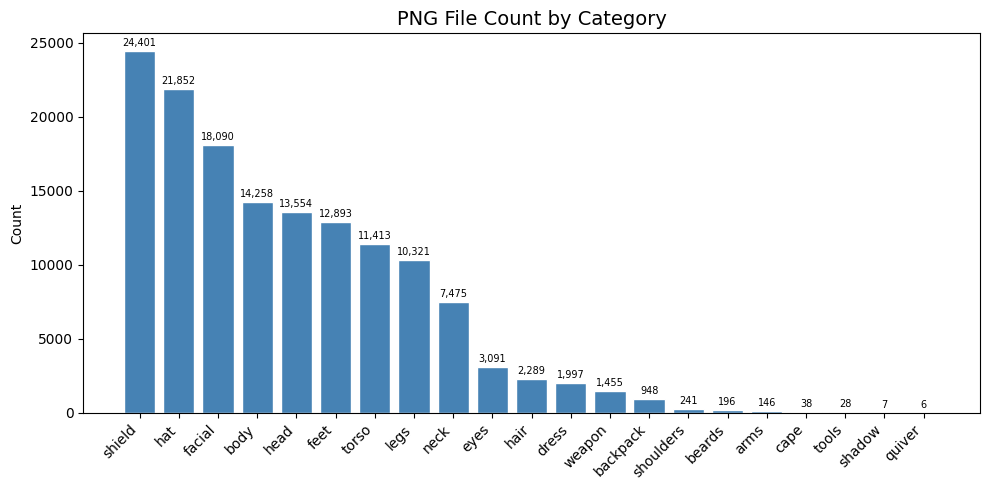

In [4]:
cats, counts = zip(*category_counts.most_common())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cats, counts, color='steelblue', edgecolor='white')
ax.set_title('PNG File Count by Category', fontsize=14)
ax.set_ylabel('Count')
ax.set_xticks(range(len(cats)))
ax.set_xticklabels(cats, rotation=45, ha='right')
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{cnt:,}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

## 3. 스프라이트시트 이미지 크기 분포

In [5]:
size_counts = Counter()
mode_counts = Counter()
sampled = 0

for png in SPRITESHEETS.rglob('*.png'):
    try:
        img = Image.open(png)
        size_counts[img.size] += 1
        mode_counts[img.mode] += 1
        sampled += 1
    except Exception:
        pass
    if sampled >= 3000:
        break

print(f'샘플 수: {sampled:,}개')
print('\n=== 이미지 크기 상위 10 ===')
for size, cnt in size_counts.most_common(10):
    fw, fh = size[0] // 64, size[1] // 64
    print(f'  {size[0]:4d}x{size[1]:3d}  ({fw}x{fh} frames)  →  {cnt}개')
print('\n=== 색상 모드 ===')
for mode, cnt in mode_counts.most_common():
    print(f'  {mode}: {cnt}개')

샘플 수: 3,000개

=== 이미지 크기 상위 10 ===
   128x256  (2x4 frames)  →  518개
   832x256  (13x4 frames)  →  485개
   192x256  (3x4 frames)  →  342개
   320x256  (5x4 frames)  →  339개
   384x256  (6x4 frames)  →  333개
   512x256  (8x4 frames)  →  333개
   384x 64  (6x1 frames)  →  321개
   576x256  (9x4 frames)  →  167개
   448x256  (7x4 frames)  →  162개

=== 색상 모드 ===
  P: 3000개


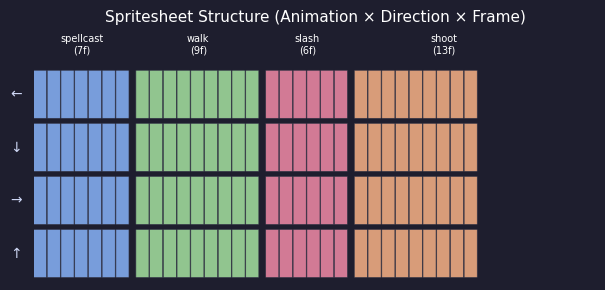

In [6]:
# 스프라이트시트 구조 설명 다이어그램
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_xlim(0, 9)
ax.set_ylim(0, 4)
ax.set_aspect('equal')
ax.set_facecolor('#1e1e2e')
fig.patch.set_facecolor('#1e1e2e')

colors = ['#89b4fa', '#a6e3a1', '#f38ba8', '#fab387',
          '#cba6f7', '#89dceb', '#f9e2af', '#94e2d5', '#b4befe']
labels = ['spellcast\n(7f)', 'walk\n(9f)', 'slash\n(6f)', 'shoot\n(13f)']
frame_counts_demo = [7, 9, 6, 13]

x = 0
row_labels = ['↑', '→', '↓', '←']
for col, (label, fc) in enumerate(zip(labels, frame_counts_demo)):
    for row in range(4):
        for f in range(min(fc, 9)):  # 최대 9개만 표시
            rect = mpatches.FancyBboxPatch(
                (x + f * 0.22, row * 0.85 + 0.05),
                0.19, 0.75,
                boxstyle='round,pad=0.01',
                facecolor=colors[col % len(colors)],
                edgecolor='#313244', linewidth=0.5, alpha=0.85
            )
            ax.add_patch(rect)
    ax.text(x + fc * 0.22 / 2, 3.6, label,
            color='white', fontsize=7, ha='center', va='bottom')
    x += fc * 0.22 + 0.1

for i, rl in enumerate(row_labels):
    ax.text(-0.2, i * 0.85 + 0.42, rl, color='#cdd6f4', fontsize=10, ha='right', va='center')

ax.set_title('Spritesheet Structure (Animation × Direction × Frame)', color='white', fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()

## 4. 원본 스프라이트시트 샘플 시각화

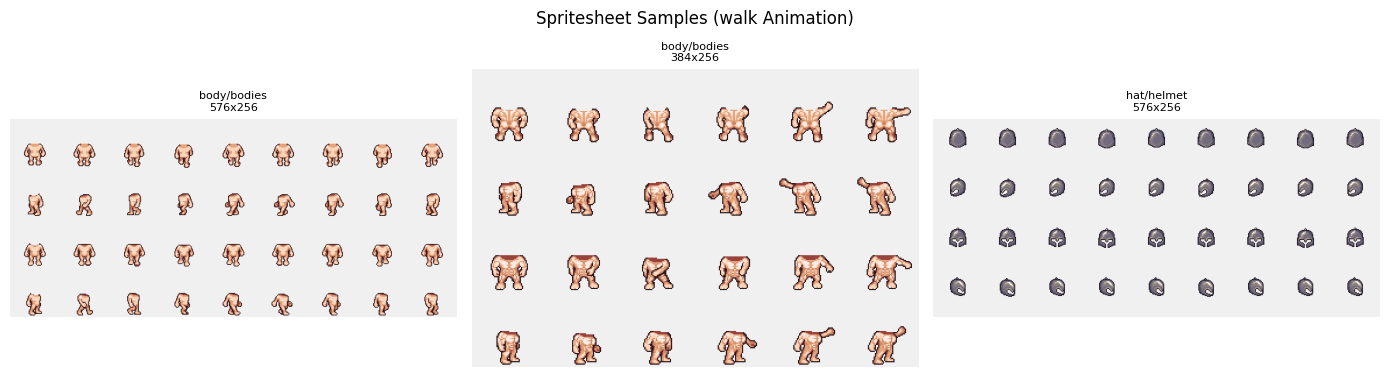

In [7]:
sample_sheets = [
    SPRITESHEETS / 'body'  / 'bodies'  / 'teen'     / 'walk.png',
    SPRITESHEETS / 'body'  / 'bodies'  / 'muscular' / 'slash.png',
    SPRITESHEETS / 'hat'   / 'helmet'  / 'barbuta_simple' / 'adult' / 'walk.png',
    SPRITESHEETS / 'feet'  / 'shoes'   / 'boots_basic_male' / 'walk.png',
]
# 존재하는 것만 필터
sample_sheets = [p for p in sample_sheets if p.exists()]
if not sample_sheets:
    # 자동 탐색
    for cat in ['body', 'hat', 'feet', 'torso', 'legs']:
        found = list((SPRITESHEETS / cat).rglob('walk.png'))[:1]
        if found:
            sample_sheets.append(found[0])
    sample_sheets = sample_sheets[:4]

fig, axes = plt.subplots(1, len(sample_sheets), figsize=(14, 4))
if len(sample_sheets) == 1:
    axes = [axes]

for ax, path in zip(axes, sample_sheets):
    img = Image.open(path).convert('RGBA')
    # 흰 배경 합성
    bg = Image.new('RGBA', img.size, (240, 240, 240, 255))
    bg.paste(img, mask=img.split()[3])
    ax.imshow(bg)
    parts = path.relative_to(SPRITESHEETS).parts
    label = '/'.join(parts[:2]) + f'\n{img.size[0]}x{img.size[1]}'
    ax.set_title(label, fontsize=8)
    ax.axis('off')

plt.suptitle('Spritesheet Samples (walk Animation)', fontsize=12)
plt.tight_layout()
plt.show()

## 5. 스프라이트시트 → 64×64 프레임 추출

시트: shield/crusader2/male/fg/walk.png
추출된 유효 프레임: 27개


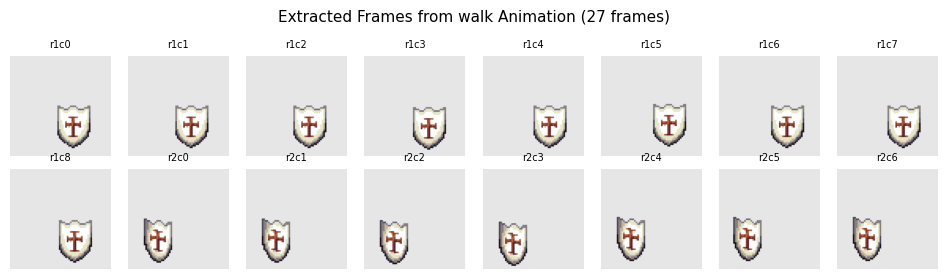

In [8]:
def extract_frames(sheet_path, frame_w=64, frame_h=64):
    """스프라이트시트에서 개별 64x64 프레임 추출."""
    img = Image.open(sheet_path).convert('RGBA')
    W, H = img.size
    cols = W // frame_w
    rows = H // frame_h
    frames = []
    for r in range(rows):
        for c in range(cols):
            box = (c * frame_w, r * frame_h, (c+1) * frame_w, (r+1) * frame_h)
            frame = img.crop(box)
            arr = np.array(frame)
            # 완전 투명 프레임 제외
            if arr[:, :, 3].max() > 0:
                frames.append((frame, r, c))
    return frames

# walk 시트에서 프레임 추출 예시
walk_sheets = list(SPRITESHEETS.rglob('walk.png'))[:1]
if walk_sheets:
    frames = extract_frames(walk_sheets[0])
    print(f'시트: {walk_sheets[0].relative_to(SPRITESHEETS)}')
    print(f'추출된 유효 프레임: {len(frames)}개')

    n = min(len(frames), 16)
    cols_vis = 8
    rows_vis = (n + cols_vis - 1) // cols_vis
    fig, axes = plt.subplots(rows_vis, cols_vis, figsize=(cols_vis * 1.2, rows_vis * 1.4))
    axes = np.array(axes).flatten()

    for i, (frame, r, c) in enumerate(frames[:n]):
        bg = Image.new('RGBA', frame.size, (230, 230, 230, 255))
        bg.paste(frame, mask=frame.split()[3])
        axes[i].imshow(bg)
        axes[i].set_title(f'r{r}c{c}', fontsize=7)
        axes[i].axis('off')
    for ax in axes[n:]:
        ax.axis('off')

    plt.suptitle(f'Extracted Frames from walk Animation ({len(frames)} frames)', fontsize=11)
    plt.tight_layout()
    plt.show()

## 6. processed/body 분석 (기존 추출 데이터)

processed/body 총 파일: 5402개


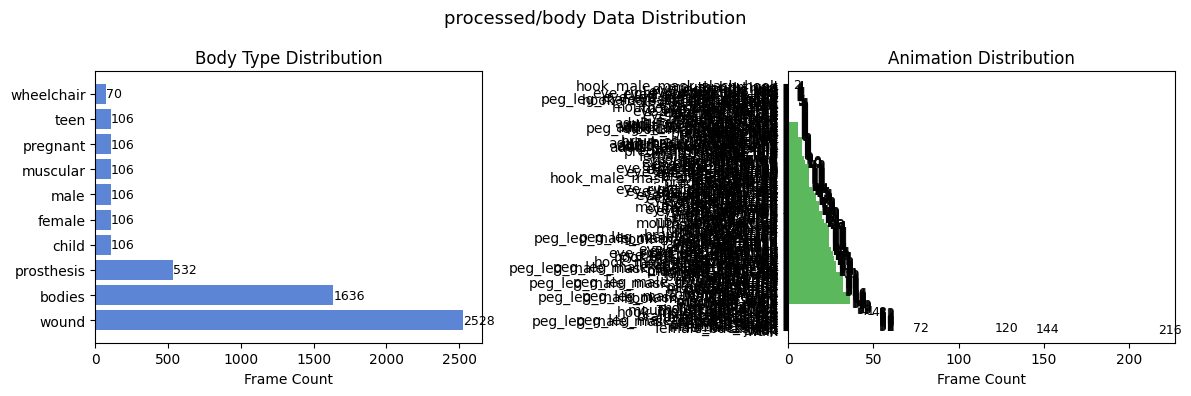

In [9]:
proc_files = sorted(PROCESSED.glob('*.png'))
print(f'processed/body 총 파일: {len(proc_files)}개')

body_types = Counter()
anims      = Counter()

for p in proc_files:
    parts = p.stem.split('_')
    body_types[parts[0]] += 1
    anim = '_'.join(parts[1:-2])
    anims[anim] += 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

bt_names, bt_counts = zip(*body_types.most_common())
ax1.barh(bt_names, bt_counts, color='#5c85d6')
ax1.set_title('Body Type Distribution')
ax1.set_xlabel('Frame Count')
for i, v in enumerate(bt_counts):
    ax1.text(v + 1, i, str(v), va='center', fontsize=9)

an_names, an_counts = zip(*anims.most_common())
ax2.barh(an_names, an_counts, color='#5cb85c')
ax2.set_title('Animation Distribution')
ax2.set_xlabel('Frame Count')
for i, v in enumerate(an_counts):
    ax2.text(v + 1, i, str(v), va='center', fontsize=9)

plt.suptitle('processed/body Data Distribution', fontsize=13)
plt.tight_layout()
plt.show()

## 7. 단일 프레임 픽셀 분석

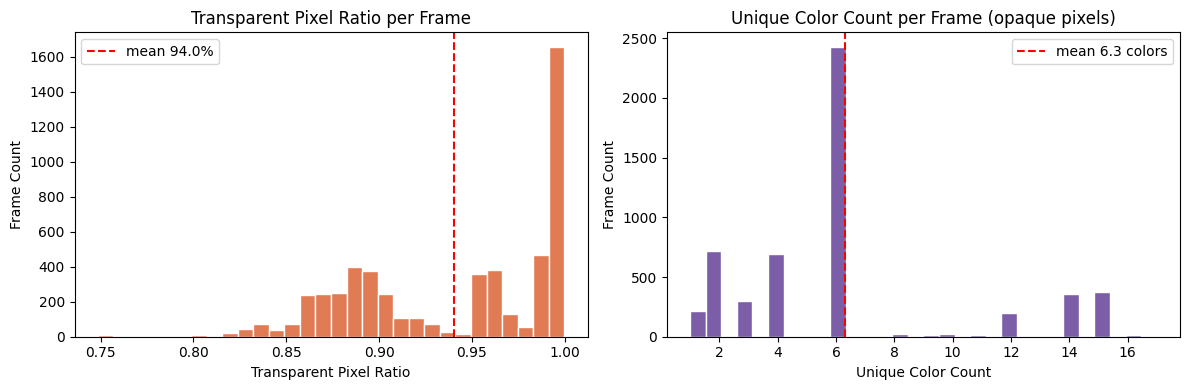

투명 비율  — mean: 94.0%, min: 74.9%, max: 100.0%
고유 색상  — mean: 6.3, min: 1, max: 17


In [10]:
# 알파(투명도) 통계
alpha_ratios = []
color_counts = []

for p in proc_files:
    arr = np.array(Image.open(p))
    alpha_ratios.append((arr[:, :, 3] == 0).mean())
    mask = arr[:, :, 3] > 0
    rgb = arr[:, :, :3][mask]
    color_counts.append(len(set(map(tuple, rgb))))

alpha_ratios = np.array(alpha_ratios)
color_counts = np.array(color_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(alpha_ratios, bins=30, color='#e07b54', edgecolor='white')
axes[0].axvline(alpha_ratios.mean(), color='red', linestyle='--',
                label=f'mean {alpha_ratios.mean():.1%}')
axes[0].set_title('Transparent Pixel Ratio per Frame')
axes[0].set_xlabel('Transparent Pixel Ratio')
axes[0].set_ylabel('Frame Count')
axes[0].legend()

axes[1].hist(color_counts, bins=30, color='#7b5ea7', edgecolor='white')
axes[1].axvline(color_counts.mean(), color='red', linestyle='--',
                label=f'mean {color_counts.mean():.1f} colors')
axes[1].set_title('Unique Color Count per Frame (opaque pixels)')
axes[1].set_xlabel('Unique Color Count')
axes[1].set_ylabel('Frame Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'투명 비율  — mean: {alpha_ratios.mean():.1%}, min: {alpha_ratios.min():.1%}, max: {alpha_ratios.max():.1%}')
print(f'고유 색상  — mean: {color_counts.mean():.1f}, min: {color_counts.min()}, max: {color_counts.max()}')

## 8. processed 샘플 시각화

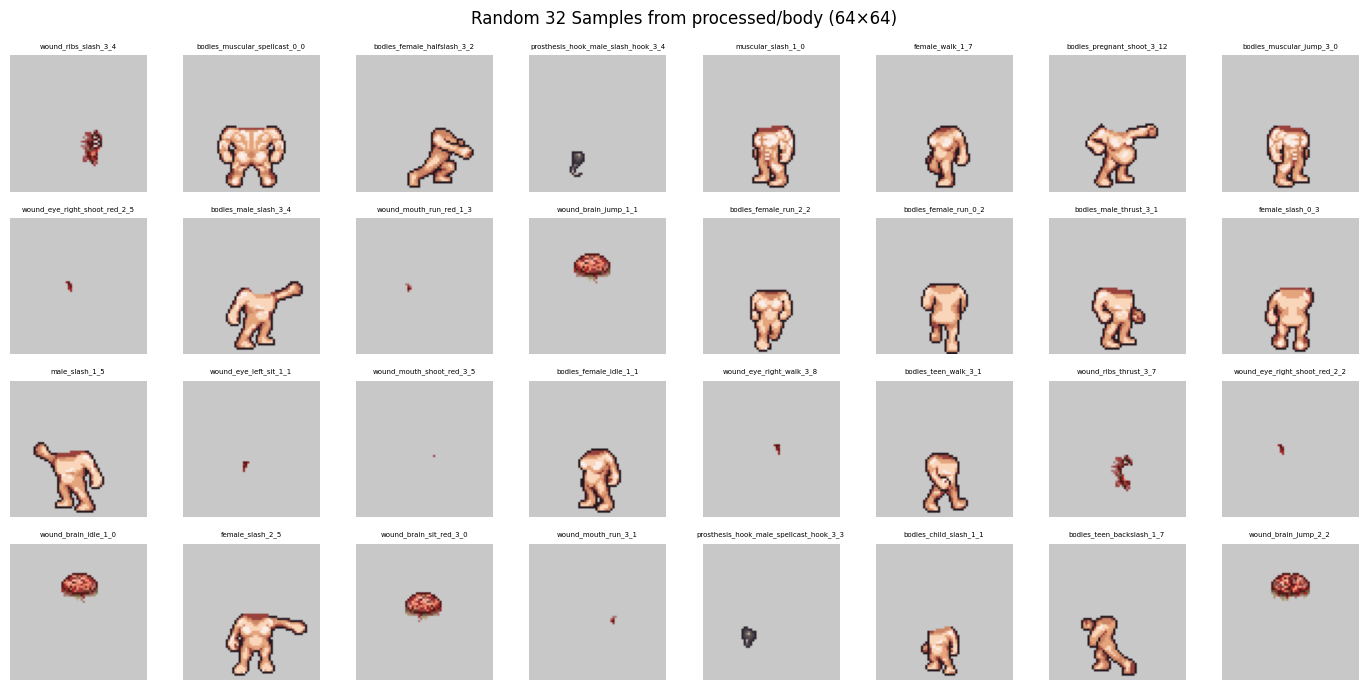

In [11]:
import random
random.seed(42)
samples = random.sample(proc_files, min(32, len(proc_files)))

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
axes = axes.flatten()

for ax, path in zip(axes, samples):
    img = Image.open(path)
    bg = Image.new('RGBA', img.size, (200, 200, 200, 255))
    bg.paste(img, mask=img.split()[3])
    ax.imshow(bg)
    ax.set_title(path.stem, fontsize=5)
    ax.axis('off')

for ax in axes[len(samples):]:
    ax.axis('off')

plt.suptitle('Random 32 Samples from processed/body (64×64)', fontsize=12)
plt.tight_layout()
plt.show()

## 9. 체형 × 애니메이션 그리드 시각화

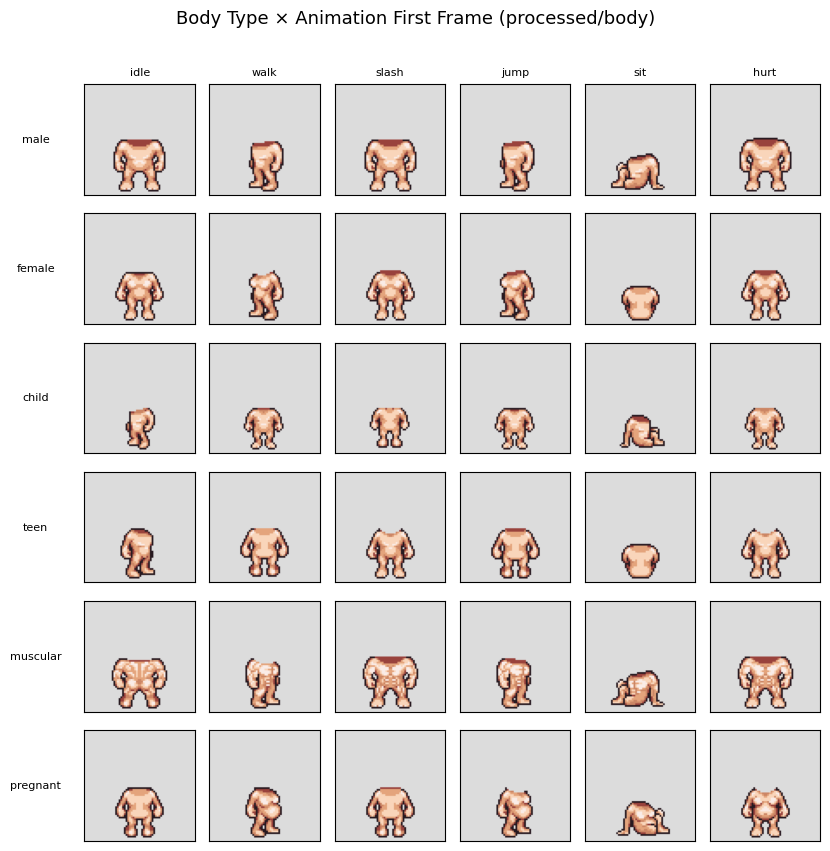

In [12]:
body_order = ['male', 'female', 'child', 'teen', 'muscular', 'pregnant']
anim_order = ['idle', 'walk', 'slash', 'jump', 'sit', 'hurt']

fig, axes = plt.subplots(len(body_order), len(anim_order),
                          figsize=(len(anim_order) * 1.4, len(body_order) * 1.4))

for ri, body in enumerate(body_order):
    for ci, anim in enumerate(anim_order):
        ax = axes[ri][ci]
        # 해당 조합의 파일 찾기 (첫 번째 프레임 0_0)
        candidates = list(PROCESSED.glob(f'{body}_{anim}_*_0.png'))
        if not candidates:
            candidates = list(PROCESSED.glob(f'{body}_{anim}_*.png'))[:1]
        
        if candidates:
            img = Image.open(candidates[0])
            bg = Image.new('RGBA', img.size, (220, 220, 220, 255))
            bg.paste(img, mask=img.split()[3])
            ax.imshow(bg)
        else:
            ax.set_facecolor('#ffcccc')
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, fontsize=7, color='gray')
        
        if ri == 0:
            ax.set_title(anim, fontsize=8)
        if ci == 0:
            ax.set_ylabel(body, fontsize=8, rotation=0, labelpad=35, va='center')
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Body Type × Animation First Frame (processed/body)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 10. 팔레트 분석

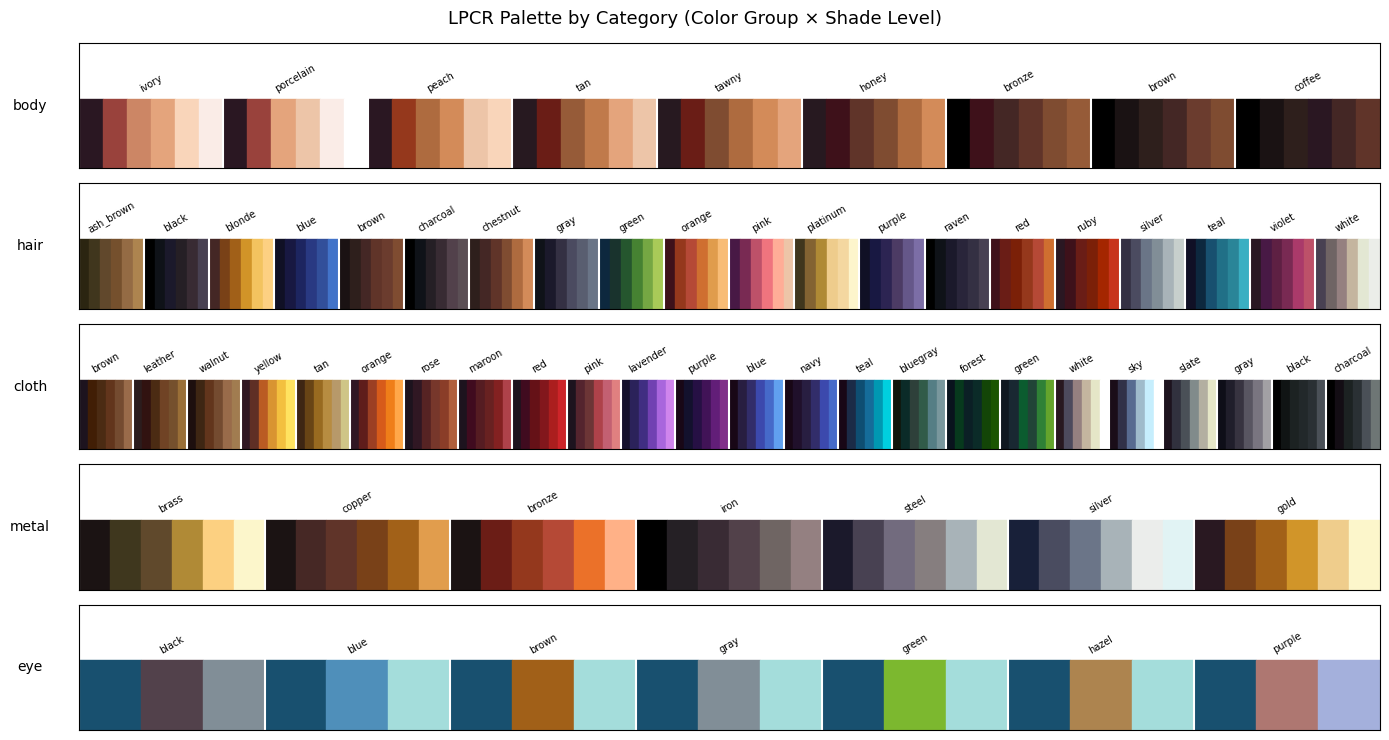

In [13]:
palette_files = {
    'body' : PALETTES / 'body'  / 'body_lpcr.json',
    'hair' : PALETTES / 'hair'  / 'hair_lpcr.json',
    'cloth': PALETTES / 'cloth' / 'cloth_ulpc.json',
    'metal': PALETTES / 'metal' / 'metal_lpcr.json',
    'eye'  : PALETTES / 'eye'   / 'eye_lpcr.json',
}

fig, axes = plt.subplots(len(palette_files), 1,
                          figsize=(14, len(palette_files) * 1.5))

for ax, (category, path) in zip(axes, palette_files.items()):
    if not path.exists():
        ax.axis('off')
        continue
    with open(path) as f:
        data = json.load(f)
    
    swatch_colors = []
    swatch_labels = []
    for color_name, hex_list in data.items():
        if isinstance(hex_list, list):
            for hex_color in hex_list:
                swatch_colors.append(hex_color)
            swatch_labels.append(color_name)
    
    # 색상 스와치 그리기
    n = len(swatch_colors)
    for i, hx in enumerate(swatch_colors):
        rect = plt.Rectangle([i, 0], 1, 1, color=hx)
        ax.add_patch(rect)
    
    # 각 컬러 그룹 구분선
    palette_sizes = [len(v) for v in data.values() if isinstance(v, list)]
    x = 0
    for size, label in zip(palette_sizes, swatch_labels):
        ax.text(x + size / 2, 1.1, label, ha='center', fontsize=7, rotation=30)
        ax.axvline(x, color='white', linewidth=1.5)
        x += size
    
    ax.set_xlim(0, n)
    ax.set_ylim(0, 1.8)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_ylabel(category, fontsize=10, rotation=0, labelpad=35, va='center')

plt.suptitle('LPCR Palette by Category (Color Group × Shade Level)', fontsize=13)
plt.tight_layout()
plt.show()

## 11. VAE 전처리 파이프라인 시뮬레이션

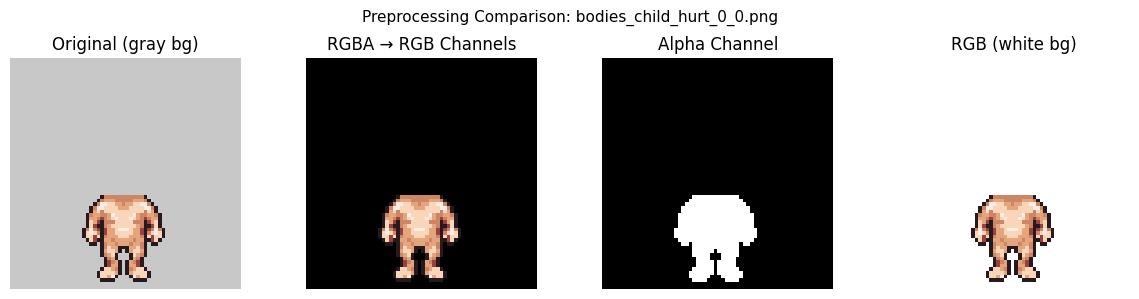

RGBA 텐서 shape: (64, 64, 4), range: [0.00, 1.00]
RGB  텐서 shape: (64, 64, 3),  range: [0.10, 1.00]


In [14]:
def preprocess_for_vae(img_path, mode='rgba'):
    """
    단일 64x64 프레임을 VAE 학습용 텐서로 변환.
    mode='rgba' : 4채널 [0,1]
    mode='rgb'  : 3채널 [0,1] (투명 → 흰 배경)
    """
    img = Image.open(img_path).convert('RGBA')
    assert img.size == (64, 64), f'크기 불일치: {img.size}'

    if mode == 'rgba':
        arr = np.array(img, dtype=np.float32) / 255.0
    elif mode == 'rgb':
        bg = Image.new('RGBA', img.size, (255, 255, 255, 255))
        bg.paste(img, mask=img.split()[3])
        arr = np.array(bg.convert('RGB'), dtype=np.float32) / 255.0
    
    return arr  # (64, 64, C)

# 전처리 전후 비교
sample_path = proc_files[0]
arr_rgba = preprocess_for_vae(sample_path, mode='rgba')
arr_rgb  = preprocess_for_vae(sample_path, mode='rgb')

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

# 원본
bg = Image.new('RGBA', (64,64), (200,200,200,255))
orig = Image.open(sample_path)
bg.paste(orig, mask=orig.split()[3])
axes[0].imshow(bg)
axes[0].set_title('Original (gray bg)')

# RGBA 4채널
axes[1].imshow(arr_rgba[:, :, :3])
axes[1].set_title('RGBA → RGB Channels')

axes[2].imshow(arr_rgba[:, :, 3], cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Alpha Channel')

axes[3].imshow(arr_rgb)
axes[3].set_title('RGB (white bg)')

for ax in axes:
    ax.axis('off')

plt.suptitle(f'Preprocessing Comparison: {sample_path.name}', fontsize=11)
plt.tight_layout()
plt.show()

print(f'RGBA 텐서 shape: {arr_rgba.shape}, range: [{arr_rgba.min():.2f}, {arr_rgba.max():.2f}]')
print(f'RGB  텐서 shape: {arr_rgb.shape},  range: [{arr_rgb.min():.2f}, {arr_rgb.max():.2f}]')

## 12. 데이터 확장 가능 규모 추정

샘플 5,000개 기준 프레임 합계: 116,938
전체 PNG 대비 비율: 28.9x
추정 총 추출 가능 프레임: ~3,384,162개


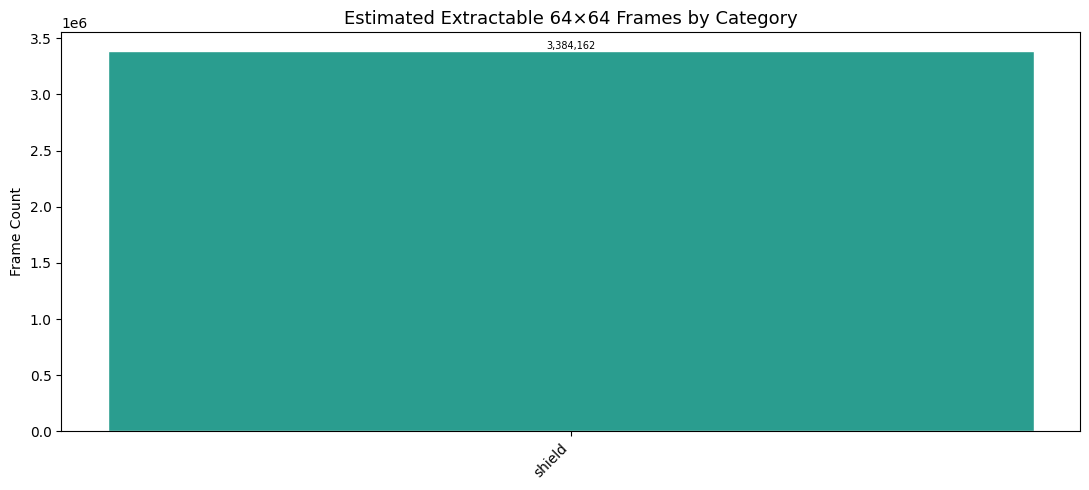

In [15]:
# 스프라이트시트에서 추출 가능한 총 64x64 프레임 수 추정
total_frames = 0
size_to_frames = {
    (128, 256): 8,   (192, 256): 12,  (320, 256): 20,
    (384, 256): 24,  (448, 256): 28,  (512, 256): 32,
    (576, 256): 36,  (832, 256): 52,  (384,  64):  6,
    (128, 128):  4,
}

per_cat = {}
sampled2 = 0
for png in SPRITESHEETS.rglob('*.png'):
    try:
        img = Image.open(png)
        w, h = img.size
        frames = (w // 64) * (h // 64)
        cat = png.relative_to(SPRITESHEETS).parts[0]
        per_cat[cat] = per_cat.get(cat, 0) + frames
        total_frames += frames
        sampled2 += 1
    except Exception:
        pass
    if sampled2 >= 5000:
        break

# 전체 추정 (샘플 비율로 보정)
ratio = total / sampled2  # total = 전체 png 수
estimated_total = int(total_frames * ratio)

print(f'샘플 {sampled2:,}개 기준 프레임 합계: {total_frames:,}')
print(f'전체 PNG 대비 비율: {ratio:.1f}x')
print(f'추정 총 추출 가능 프레임: ~{estimated_total:,}개')

# 시각화
cats_sorted = sorted(per_cat.items(), key=lambda x: -x[1])
c_names, c_vals = zip(*cats_sorted)
c_vals_est = [int(v * ratio) for v in c_vals]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(c_names, c_vals_est, color='#2a9d8f', edgecolor='white')
ax.set_title('Estimated Extractable 64×64 Frames by Category', fontsize=13)
ax.set_ylabel('Frame Count')
ax.set_xticks(range(len(c_names)))
ax.set_xticklabels(c_names, rotation=45, ha='right')
for bar, v in zip(bars, c_vals_est):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{v:,}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

## 13. 분석 요약 및 VAE 권고사항

In [16]:
summary = {
    '원본 PNG 파일 수': f'{total:,}',
    '카테고리 수': len(category_counts),
    '단일 프레임 크기': '64 × 64 px',
    '색상 채널': 'RGBA (4ch)',
    '평균 투명 픽셀 비율': f'{alpha_ratios.mean():.1%}',
    '평균 고유 색상 수': f'{color_counts.mean():.1f}색 (팔레트 기반)',
    'processed/body 프레임': f'{len(proc_files)}개',
    '체형 종류': ', '.join(body_order),
    '애니메이션 종류': ', '.join(anim_order),
}

recommendations = [
    ('입력 크기', '64×64 고정 → 전처리 불필요'),
    ('채널', 'RGBA 4채널 권장 (알파로 배경/전경 분리)'),
    ('정규화', '[0,1] float32 (÷255)'),
    ('데이터 확장', '스프라이트시트 전체 크롭 → 수십만 프레임 확보 가능'),
    ('모델 선택', 'body만 → 단순 VAE / 전 카테고리 → 조건부 cVAE 권장'),
    ('필터링', '알파 max=0인 완전 투명 프레임 제거'),
    ('클래스 불균형', 'shield(24K) vs quiver(6개) → 카테고리별 샘플링 필요'),
]

print('=' * 55)
print('  데이터셋 분석 요약')
print('=' * 55)
for k, v in summary.items():
    print(f'  {k:<22s}: {v}')

print()
print('=' * 55)
print('  VAE 구현 권고사항')
print('=' * 55)
for k, v in recommendations:
    print(f'  [{k}] {v}')

  데이터셋 분석 요약
  원본 PNG 파일 수           : 144,699
  카테고리 수                : 21
  단일 프레임 크기             : 64 × 64 px
  색상 채널                 : RGBA (4ch)
  평균 투명 픽셀 비율           : 94.0%
  평균 고유 색상 수            : 6.3색 (팔레트 기반)
  processed/body 프레임    : 5402개
  체형 종류                 : male, female, child, teen, muscular, pregnant
  애니메이션 종류              : idle, walk, slash, jump, sit, hurt

  VAE 구현 권고사항
  [입력 크기] 64×64 고정 → 전처리 불필요
  [채널] RGBA 4채널 권장 (알파로 배경/전경 분리)
  [정규화] [0,1] float32 (÷255)
  [데이터 확장] 스프라이트시트 전체 크롭 → 수십만 프레임 확보 가능
  [모델 선택] body만 → 단순 VAE / 전 카테고리 → 조건부 cVAE 권장
  [필터링] 알파 max=0인 완전 투명 프레임 제거
  [클래스 불균형] shield(24K) vs quiver(6개) → 카테고리별 샘플링 필요
